# Análise de Vendas com Pandas, NumPy, Matplotlib e Seaborn

Este notebook cria um conjunto de dados fictício de vendas, trata valores ausentes, realiza análises e gera gráficos e um relatório CSV.

## 1. Criar o arquivo CSV fictício

Gera 100 registros de vendas e insere alguns valores ausentes para praticar o tratamento de dados.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


np.random.seed(42)
n_linhas = 100

datas = pd.date_range(start="2024-01-01", end="2024-12-31", periods=n_linhas)
lojas = np.random.choice(["Loja A", "Loja B", "Loja C", "Loja D"], size=n_linhas)
produtos = np.random.choice(["Produto X", "Produto Y", "Produto Z", "Produto W"], size=n_linhas)
regioes = np.random.choice(["Norte", "Sul", "Este", "Oeste"], size=n_linhas)
categorias = np.random.choice(["Eletrónicos", "Vestuário", "Higiene", "Alimentação"], size=n_linhas)
quantidades = np.random.randint(1, 10, size=n_linhas).astype(float)
precos = np.random.uniform(10.0, 500.0, size=n_linhas)

# Inserir valores ausentes intencionais
quantidades[np.random.choice(n_linhas, 5, replace=False)] = np.nan
precos[np.random.choice(n_linhas, 5, replace=False)] = np.nan

df_ficticio = pd.DataFrame({
    "data": datas.strftime("%Y-%m-%d"),
    "loja": lojas,
    "produto": produtos,
    "regiao": regioes,
    "categoria": categorias,
    "quantidade": quantidades,
    "preco_unitario": precos,
})

df_ficticio.to_csv("vendas.csv", index=False)
print("Arquivo 'vendas.csv' criado com sucesso!")

Arquivo 'vendas.csv' criado com sucesso!


## 2. Importar bibliotecas e carregar os dados

Lê o CSV e converte a coluna `data` para o formato de data do Pandas.

In [2]:

df = pd.read_csv("vendas.csv")
df["data"] = pd.to_datetime(df["data"])

df.head()

,data,loja,produto,regiao,categoria,quantidade,preco_unitario
0,2024-01-01,Loja C,Produto Z,Este,Eletrónicos,8.0,85.970392
1,2024-01-04,Loja D,Produto Y,Oeste,Eletrónicos,4.0,491.102035
2,2024-01-08,Loja A,Produto Y,Este,Higiene,1.0,421.077416
3,2024-01-12,Loja C,Produto W,Norte,Vestuário,8.0,NaN
4,2024-01-15,Loja C,Produto Y,Oeste,Vestuário,4.0,132.623167


## 3. Criar a coluna de faturamento

O faturamento de cada registro é calculado multiplicando a quantidade pelo preço unitário.

In [3]:
df["faturamento"] = df["quantidade"] * df["preco_unitario"]
df.head()

,data,loja,produto,regiao,categoria,quantidade,preco_unitario,faturamento
0,2024-01-01,Loja C,Produto Z,Este,Eletrónicos,8.0,85.970392,687.763138
1,2024-01-04,Loja D,Produto Y,Oeste,Eletrónicos,4.0,491.102035,1964.408141
2,2024-01-08,Loja A,Produto Y,Este,Higiene,1.0,421.077416,421.077416
3,2024-01-12,Loja C,Produto W,Norte,Vestuário,8.0,NaN,NaN
4,2024-01-15,Loja C,Produto Y,Oeste,Vestuário,4.0,132.623167,530.492667


## 4. Verificar a integridade dos dados

Exibe informações gerais, valores ausentes e estatísticas descritivas.

In [4]:
print("--- Informações do DataFrame ---")
df.info()

print("\n--- Valores ausentes por coluna ---")
print(df.isnull().sum())

print("\n--- Resumo estatístico ---")
print(df.describe())

--- Informações do DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            100 non-null    datetime64[us]
 1   loja            100 non-null    str           
 2   produto         100 non-null    str           
 3   regiao          100 non-null    str           
 4   categoria       100 non-null    str           
 5   quantidade      95 non-null     float64       
 6   preco_unitario  95 non-null     float64       
 7   faturamento     91 non-null     float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 6.4 KB

--- Valores ausentes por coluna ---
data              0
loja              0
produto           0
regiao            0
categoria         0
quantidade        5
preco_unitario    5
faturamento       9
dtype: int64

--- Resumo estatístico ---
                      data  quantidade  preco_unit

## 5. Tratar valores ausentes

Substitui os valores ausentes de `preco_unitario` e `quantidade` pela média de cada coluna e recalcula o faturamento.

In [5]:
df["preco_unitario"] = df["preco_unitario"].fillna(df["preco_unitario"].mean())
df["quantidade"] = df["quantidade"].fillna(df["quantidade"].mean())
df["faturamento"] = df["quantidade"] * df["preco_unitario"]

print("Valores ausentes após o tratamento:")
print(df.isnull().sum())

Valores ausentes após o tratamento:
data              0
loja              0
produto           0
regiao            0
categoria         0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64


## 6. Criar colunas de mês

As colunas `mes` e `mes_ano` serão utilizadas nas análises mensais e na matriz de correlação.

In [6]:
df["mes"] = df["data"].dt.month
df["mes_ano"] = df["data"].dt.strftime("%m/%Y")
df[["data", "mes", "mes_ano"]].head()

,data,mes,mes_ano
0,2024-01-01,1,01/2024
1,2024-01-04,1,01/2024
2,2024-01-08,1,01/2024
3,2024-01-12,1,01/2024
4,2024-01-15,1,01/2024


## 7. Faturamento total por loja

Agrupa as vendas por loja e ordena o faturamento do maior para o menor.

In [7]:
faturamento_por_loja = df.groupby("loja")["faturamento"].sum().sort_values(ascending=False)
print("--- Faturamento total por loja ---")
print(faturamento_por_loja)

--- Faturamento total por loja ---
loja
Loja D    35007.552717
Loja B    30189.238535
Loja C    29689.192093
Loja A    24440.142278
Name: faturamento, dtype: float64


## 8. Ticket médio por loja

Calcula o faturamento médio por registro de venda em cada loja.

In [8]:
ticket_medio = df.groupby("loja")["faturamento"].mean()
print("--- Ticket médio por loja ---")
print(ticket_medio)

--- Ticket médio por loja ---
loja
Loja A    1222.007114
Loja B    1161.124559
Loja C    1237.049671
Loja D    1166.918424
Name: faturamento, dtype: float64


## 9. Cinco produtos mais vendidos

Soma as quantidades vendidas por produto e ordena da maior para a menor. Como há quatro produtos no conjunto fictício, serão exibidos até quatro resultados.

In [9]:
top5_produtos = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False).head(5)
print("--- Produtos mais vendidos em quantidade ---")
print(top5_produtos)

--- Produtos mais vendidos em quantidade ---
produto
Produto Z    160.410526
Produto X    133.410526
Produto W     89.705263
Produto Y     87.000000
Name: quantidade, dtype: float64


## 10. Mês de maior e menor faturamento

Agrupa o faturamento por mês e identifica os meses com os valores máximo e mínimo.

In [10]:
faturamento_mensal = df.groupby("mes_ano")["faturamento"].sum()
mes_maior = faturamento_mensal.idxmax()
mes_menor = faturamento_mensal.idxmin()

print(f"Mês com maior faturamento: {mes_maior} (R$ {faturamento_mensal[mes_maior]:.2f})")
print(f"Mês com menor faturamento: {mes_menor} (R$ {faturamento_mensal[mes_menor]:.2f})")

Mês com maior faturamento: 09/2024 (R$ 14963.79)
Mês com menor faturamento: 06/2024 (R$ 3465.55)


## 11. Configurar o estilo e criar a pasta dos gráficos

In [11]:
sns.set_style("whitegrid")
sns.set_palette("deep")
os.makedirs("graficos", exist_ok=True)
print("Pasta 'graficos' pronta para receber os arquivos.")

Pasta 'graficos' pronta para receber os arquivos.


## 12. Gráfico de barras — faturamento por loja

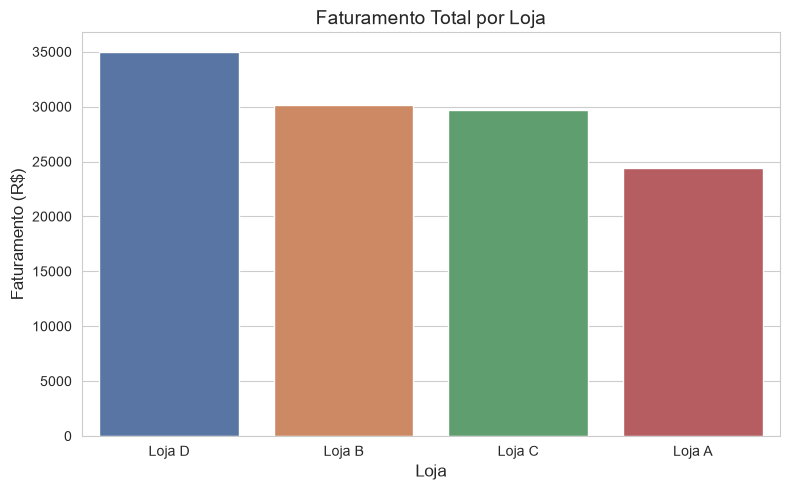

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=faturamento_por_loja.index, y=faturamento_por_loja.values,
            hue=faturamento_por_loja.index, legend=False)
plt.title("Faturamento Total por Loja", fontsize=14)
plt.xlabel("Loja", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)
plt.tight_layout()
plt.savefig("graficos/faturamento_por_loja.png")
plt.show()

## 13. Gráfico de linhas — evolução mensal do faturamento

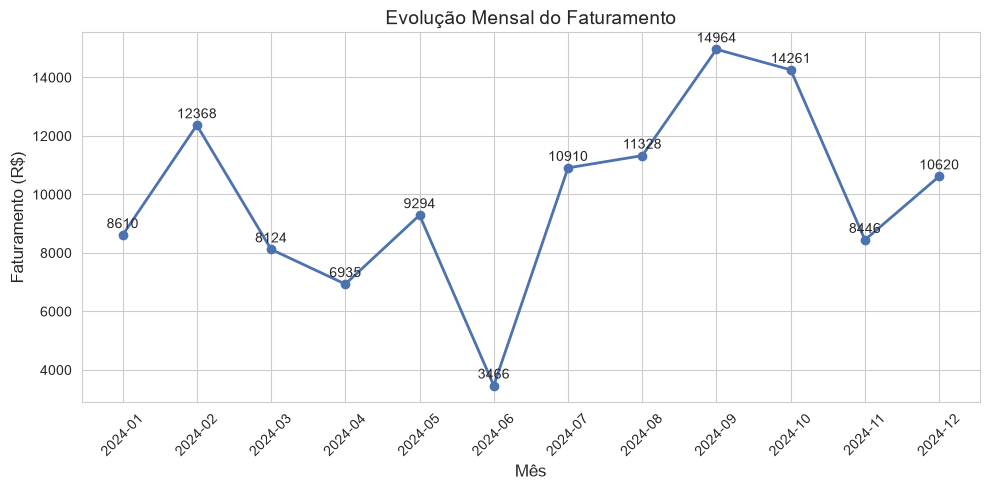

In [13]:
faturamento_por_mes = df.groupby(df["data"].dt.to_period("M"))["faturamento"].sum().reset_index()
faturamento_por_mes["data"] = faturamento_por_mes["data"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(faturamento_por_mes["data"], faturamento_por_mes["faturamento"], marker="o", linewidth=2)
for i, valor in enumerate(faturamento_por_mes["faturamento"]):
    plt.annotate(f"{valor:.0f}",
                 (faturamento_por_mes["data"].iloc[i], faturamento_por_mes["faturamento"].iloc[i]),
                 textcoords="offset points", xytext=(0, 5), ha="center")
plt.title("Evolução Mensal do Faturamento", fontsize=14)
plt.xlabel("Mês", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("graficos/evolucao_mensal_faturamento.png")
plt.show()

## 14. Gráfico de pizza — distribuição do faturamento por região

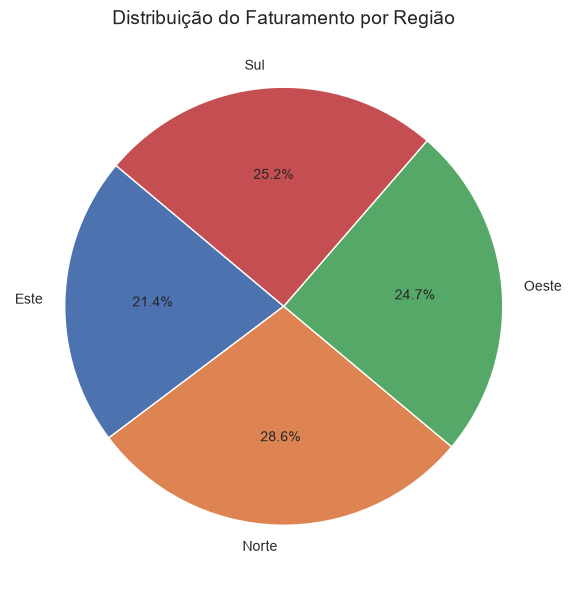

In [14]:
fat_regiao = df.groupby("regiao")["faturamento"].sum()
plt.figure(figsize=(6, 6))
plt.pie(fat_regiao, labels=fat_regiao.index, autopct="%1.1f%%", startangle=140,
        colors=sns.color_palette("deep", len(fat_regiao)))
plt.title("Distribuição do Faturamento por Região", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/faturamento_por_regiao.png")
plt.show()

## 15. Gráfico de dispersão — quantidade e faturamento

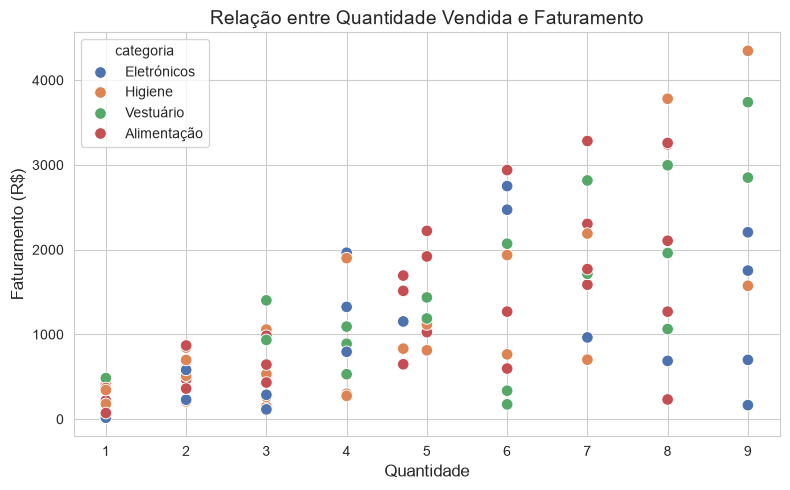

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="quantidade", y="faturamento", hue="categoria", s=70)
plt.title("Relação entre Quantidade Vendida e Faturamento", fontsize=14)
plt.xlabel("Quantidade", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)
plt.tight_layout()
plt.savefig("graficos/quantidade_vs_faturamento.png")
plt.show()

## 16. Boxplot — distribuição de preços por categoria

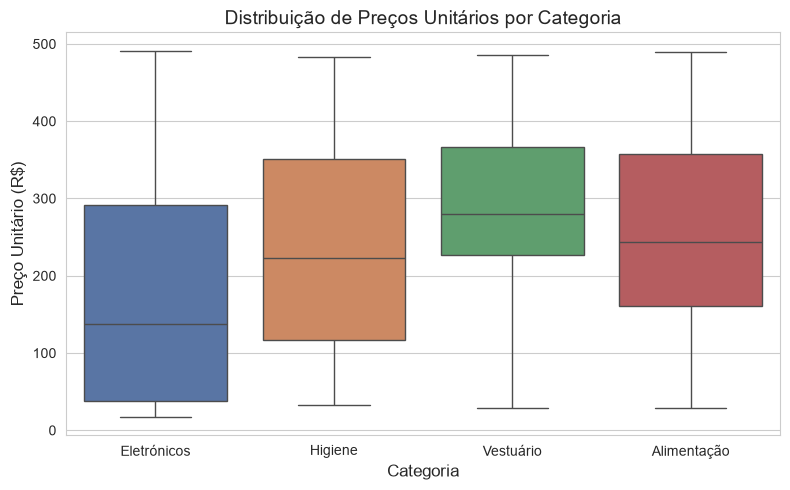

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="categoria", y="preco_unitario", hue="categoria", legend=False)
plt.title("Distribuição de Preços Unitários por Categoria", fontsize=14)
plt.xlabel("Categoria", fontsize=12)
plt.ylabel("Preço Unitário (R$)", fontsize=12)
plt.tight_layout()
plt.savefig("graficos/boxplot_precos_categoria.png")
plt.show()

## 17. Heatmap — correlação entre variáveis numéricas

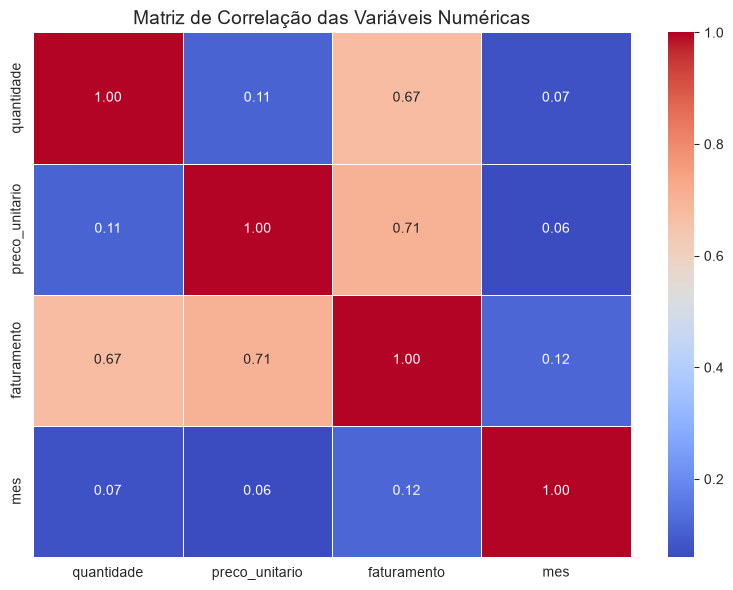

In [17]:
colunas_numericas = df[["quantidade", "preco_unitario", "faturamento", "mes"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(colunas_numericas, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=14)
plt.tight_layout()
plt.savefig("graficos/heatmap_correlacao.png")
plt.show()

## 18. Comparação de gráficos com `plt.subplots`

Exibe o faturamento por loja e por região na mesma figura.

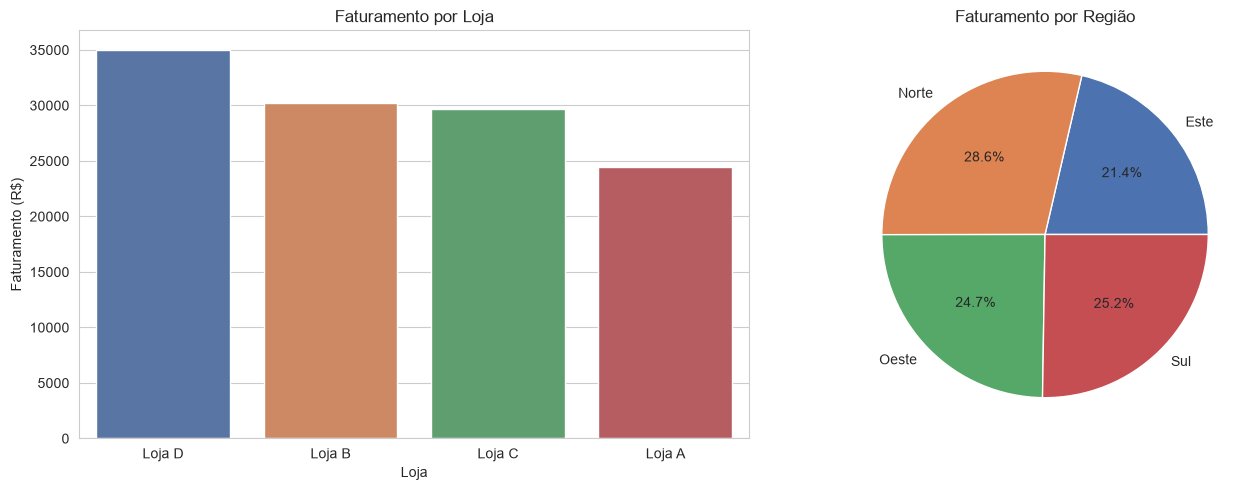

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(ax=axes[0], x=faturamento_por_loja.index, y=faturamento_por_loja.values,
            hue=faturamento_por_loja.index, legend=False)
axes[0].set_title("Faturamento por Loja", fontsize=12)
axes[0].set_xlabel("Loja")
axes[0].set_ylabel("Faturamento (R$)")

axes[1].pie(fat_regiao, labels=fat_regiao.index, autopct="%1.1f%%",
            colors=sns.color_palette("deep", len(fat_regiao)))
axes[1].set_title("Faturamento por Região", fontsize=12)

plt.tight_layout()
plt.savefig("graficos/comparacao_loja_regiao.png")
plt.show()

## 19. Exportar o relatório analítico

Cria um CSV com o faturamento total, a loja com maior faturamento e o mês de maior faturamento.

In [19]:
resumo_analitico = pd.DataFrame({
    "Métrica": [
        "Faturamento Total",
        "Loja com Maior Faturamento",
        "Mês de Maior Faturamento",
    ],
    "Valor": [
        f"R$ {df['faturamento'].sum():.2f}",
        faturamento_por_loja.index[0],
        mes_maior,
    ],
})

resumo_analitico.to_csv("resumo_analitico.csv", index=False)
print("Relatório 'resumo_analitico.csv' gerado com sucesso!")
resumo_analitico

Relatório 'resumo_analitico.csv' gerado com sucesso!


,Métrica,Valor
0,Faturamento Total,R$ 119326.13
1,Loja com Maior Faturamento,Loja D
2,Mês de Maior Faturamento,09/2024
